# Exploring Childcare Affordability Trends Using Data Analytics

## Project Overview

This project analyzes childcare affordability trends across the United States using the National Database of Childcare Prices.

The analysis examines childcare costs by year, state, provider type, child age group, household income, and price range. Cleaned data is saved to the `results` folder, while generated visualizations are saved to the `figures` folder.


## 1. Import Libraries

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from IPython.display import display

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)


## 2. Set Project Paths

In [2]:
CURRENT_DIR = Path.cwd()

# Support running the notebook from either the project root
# or from inside the notebooks folder.
if CURRENT_DIR.name.lower() == "notebooks":
    PROJECT_DIR = CURRENT_DIR.parent
else:
    PROJECT_DIR = CURRENT_DIR

DATA_DIR = PROJECT_DIR / "data"
FIGURES_DIR = PROJECT_DIR / "figures"
RESULTS_DIR = PROJECT_DIR / "results"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Project directory:", PROJECT_DIR)
print("Data directory:", DATA_DIR)
print("Figures directory:", FIGURES_DIR)
print("Results directory:", RESULTS_DIR)


Project directory: C:\Mathan\GitHub\Mathan-MS.github.io\mathan-ms.github.io\Projects\Childcare_Cost_Analysis
Data directory: C:\Mathan\GitHub\Mathan-MS.github.io\mathan-ms.github.io\Projects\Childcare_Cost_Analysis\data
Figures directory: C:\Mathan\GitHub\Mathan-MS.github.io\mathan-ms.github.io\Projects\Childcare_Cost_Analysis\figures
Results directory: C:\Mathan\GitHub\Mathan-MS.github.io\mathan-ms.github.io\Projects\Childcare_Cost_Analysis\results


## 3. Load the Dataset

In [3]:
file_name = "nationaldatabaseofchildcareprices.xlsx"
file_path = DATA_DIR / file_name

df = pd.read_excel(file_path)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

display(df.head())


Dataset loaded successfully.
Shape: (34567, 227)


,State_Name,State_Abbreviation,County_Name,County_FIPS_Code,StudyYear,UNR_16,FUNR_16,MUNR_16,UNR_20to64,FUNR_20to64,MUNR_20to64,FLFPR_20to64,FLFPR_20to64_Under6,FLFPR_20to64_6to17,FLFPR_20to64_Under6_6to17,MLFPR_20to64,PR_F,PR_P,MHI,ME,FME,MME,MHI_2018,ME_2018,FME_2018,MME_2018,TotalPop,OneRace,OneRace_W,OneRace_B,OneRace_I,OneRace_A,OneRace_H,OneRace_Other,TwoRaces,Hispanic,Households,H_Under6_BothWork,H_Under6_FWork,H_Under6_MWork,H_Under6_SingleM,H_6to17_BothWork,H_6to17_Fwork,H_6to17_Mwork,H_6to17_SingleM,EMP_M,MEMP_M,FEMP_M,EMP_Service,MEMP_Service,FEMP_Service,EMP_Sales,MEMP_Sales,FEMP_Sales,EMP_N,MEMP_N,FEMP_N,EMP_P,MEMP_P,FEMP_P,iUNR_16,iFUNR_16,iMUNR_16,iUNR_20to64,iFUNR_20to64,iMUNR_20to64,iFLFPR_20to64,iFLFPR_20to64_Under6,iFLFPR_20to64_6to17,iFLFPR_20to64_Under6_6to17,iMLFPR_20to64,iPR_F,iPR_P,iMHI,iME,iFME,iMME,iMHI_2018,iME_2018,iFME_2018,iMME_2018,iTotalPop,iOneRace,iOneRace_W,iOneRace_B,iOneRace_I,iOneRace_A,iOneRace_H,iOneRace_Other,iTwoRaces,iHispanic,iHouseholds,iH_Under6_BothWork,iH_Under6_FWork,iH_Under6_MWork,iH_Under6_SingleM,iH_6to17_BothWork,iH_6to17_Fwork,iH_6to17_Mwork,iH_6to17_SingleM,iEMP_M,iMEMP_M,iFEMP_M,iEMP_Service,iMEMP_Service,iFEMP_Service,iEMP_Sales,iMEMP_Sales,iFEMP_Sales,iEMP_N,iMEMP_N,iFEMP_N,iEMP_P,iMEMP_P,iFEMP_P,MCBto5,MC6to11,MC12to17,MC18to23,MC24to29,MC30to35,MC36to41,MC42to47,MC48to53,MC54toSA,MCSA,MFCCBto5,MFCC6to11,MFCC12to17,MFCC18to23,MFCC24to29,MFCC30to35,MFCC36to41,MFCC42to47,MFCC48to53,MFCC54toSA,MFCCSA,_75CBto5,_75C6to11,_75C12to17,_75C18to23,_75C24to29,_75C30to35,_75C36to41,_75C42to47,_75C48to53,_75C54toSA,_75CSA,_75FCCBto5,_75FCC6to11,_75FCC12to17,_75FCC18to23,_75FCC24to29,_75FCC30to35,_75FCC36to41,_75FCC42to47,_75FCC48to53,_75FCC54toSA,_75FCCSA,iMCBto5,iMC6to11,iMC12to17,iMC18to23,iMC24to29,iMC30to35,iMC36to41,iMC42to47,iMC48to53,iMC54toSA,iMCSA,iMFCCBto5,iMFCC6to11,iMFCC12to17,iMFCC18to23,iMFCC24to29,iMFCC30to35,iMFCC36to41,iMFCC42to47,iMFCC48to53,iMFCC54toSA,iMFCCSA,i_75CBto5,i_75C6to11,i_75C12to17,i_75C18to23,i_75C24to29,i_75C30to35,i_75C36to41,i_75C42to47,i_75C48to53,i_75C54toSA,i_75CSA,i_75FCCBto5,i_75FCC6to11,i_75FCC12to17,i_75FCC18to23,i_75FCC24to29,i_75FCC30to35,i_75FCC36to41,i_75FCC42to47,i_75FCC48to53,i_75FCC54toSA,i_75FCCSA,MCInfant,MCInfant_flag,MCToddler,MCToddler_flag,MCPreschool,MCPreschool_flag,_75CInfant,_75CInfant_flag,_75CToddler,_75CToddler_flag,_75CPreschool,_75CPreschool_flag,MFCCInfant,MFCCInfant_flag,MFCCToddler,MFCCToddler_flag,MFCCPreschool,MFCCPreschool_flag,_75FCCInfant,_75FCCInfant_flag,_75FCCToddler,_75FCCToddler_flag,_75FCCPreschool,_75FCCPreschool_flag
0,Alabama,AL,Autauga County,1001,2008,5.42,4.41,6.32,4.6,3.5,5.6,68.9,66.9,79.59,60.81,84.0,8.5,11.5,50837.0,28444.0,21875.0,36032.0,58462.55,32710.60,25156.25,41436.80,49744,98.1,78.9,17.7,0.4,0.4,0.0,0.7,1.9,1.8,18373,1543,970,22,995.0,4900,1308,114,1966.0,27.40,24.41,30.68,17.06,15.53,18.75,29.11,15.97,43.52,13.21,22.54,2.99,13.22,21.55,4.07,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,104.95,104.95,104.95,104.95,104.95,85.92,85.92,85.92,85.92,85.92,80.92,83.45,83.45,83.45,83.45,83.45,81.40,81.40,81.40,81.40,81.40,81.40,125.8,125.8,125.8,125.8,125.8,103.0,103.0,103.0,103.0,103.0,97.0,97.4,97.4,97.4,97.4,97.4,95.0,95.0,95.0,95.0,95.0,95.0,11.0,11.0,11.0,11.0,11.0,11.0,11.0,11.0,11.0,11.0,11.0,11.0,11.0,11.0,11.0,11.0,11.0,11.0,11.0,11.0,11.0,11.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,104.95,1.0,104.95,3.0,85.92,1.0,125.8,1.0,125.8,3.0,103.0,1.0,83.45,1.0,83.45,3.0,81.40,1.0,97.4,1.0,97.4,3.0,95.0,1.0
1,Alabama,AL,Autauga County,1001,2009,5.93,5.72,6.11,4.8,4.6,5.0,70.8,63.7,78.41,59.91,86.2,7.5,10.3,51463.0,29648.0,22951.0,37492.0,60211.71,34688.16,26852.67,43865.64,49584,98.6,79.1,17.9,0.4,0.6,0.0,0.7,1.4,2.0,18288,1475,964,16,1099.0,5028,1519,92,2305.0,29.54,26.07,33.40,15.81,14.16,17.64,28.75,17.51,41.25,11.89,20.30,2.52,14.02,21.96,5.19,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,1

## 4. Inspect the Dataset

In [4]:
structure_summary = pd.DataFrame({
    "Metric": [
        "Number of rows",
        "Number of columns",
        "Number of states",
        "Number of counties",
        "Study years range"
    ],
    "Value": [
        df.shape[0],
        df.shape[1],
        df["State_Name"].nunique(),
        df["County_FIPS_Code"].nunique(),
        f"{df['StudyYear'].min()} - {df['StudyYear'].max()}"
    ]
})

display(structure_summary)


,Metric,Value
0,Number of rows,34567
1,Number of columns,227
2,Number of states,51
3,Number of counties,3144
4,Study years range,2008 - 2018


In [5]:
column_info = pd.DataFrame({
    "Column Name": df.columns,
    "Data Type": df.dtypes.values
})

display(column_info.head(20))


,Column Name,Data Type
0,State_Name,object
1,State_Abbreviation,object
2,County_Name,object
3,County_FIPS_Code,int64
4,StudyYear,int64
5,UNR_16,float64
6,FUNR_16,float64
7,MUNR_16,float64
8,UNR_20to64,float64
9,FUNR_20to64,float64


## 5. Data Cleaning and Preparation

In [6]:
initial_rows = df.shape[0]
df = df.drop_duplicates()

print("Rows before removing duplicates:", initial_rows)
print("Rows after removing duplicates:", df.shape[0])


Rows before removing duplicates: 34567
Rows after removing duplicates: 34567


In [7]:
missing_summary = df.isna().sum().sort_values(ascending=False)

missing_table = pd.DataFrame({
    "Column": missing_summary.index,
    "Missing Values": missing_summary.values,
    "Missing %": (missing_summary.values / len(df) * 100).round(2)
})

display(missing_table.head(5))


,Column,Missing Values,Missing %
0,iMFCC12to17,11204,32.41
1,iMFCCBto5,11204,32.41
2,iMFCC54toSA,11204,32.41
3,iMFCC48to53,11204,32.41
4,iMFCC42to47,11204,32.41


In [8]:
threshold = 0.40

cols_to_drop = missing_table[
    missing_table["Missing %"] > threshold * 100
]["Column"]

df_clean = df.drop(columns=cols_to_drop)

print("Columns removed due to high missing values:", len(cols_to_drop))
print("Remaining columns:", df_clean.shape[1])


Columns removed due to high missing values: 0
Remaining columns: 227


In [9]:
selected_columns = [
    "State_Name",
    "State_Abbreviation",
    "County_Name",
    "StudyYear",
    "MCInfant",
    "MCToddler",
    "MCPreschool",
    "MFCCInfant",
    "MFCCToddler",
    "MFCCPreschool",
    "_75CInfant",
    "_75CToddler",
    "_75CPreschool",
    "MHI",
    "TotalPop",
    "Households",
    "PR_P"
]

selected_columns = [
    column for column in selected_columns
    if column in df_clean.columns
]

df_clean = df_clean[selected_columns]

print("Columns selected for analysis:")
print(df_clean.columns.tolist())


Columns selected for analysis:
['State_Name', 'State_Abbreviation', 'County_Name', 'StudyYear', 'MCInfant', 'MCToddler', 'MCPreschool', 'MFCCInfant', 'MFCCToddler', 'MFCCPreschool', '_75CInfant', '_75CToddler', '_75CPreschool', 'MHI', 'TotalPop', 'Households', 'PR_P']


In [10]:
price_columns = df_clean.columns.difference([
    "State_Name",
    "State_Abbreviation",
    "County_Name",
    "StudyYear"
])

df_clean[price_columns] = df_clean[price_columns].apply(
    pd.to_numeric,
    errors="coerce"
)

df_clean = df_clean.dropna(subset=price_columns)

print("Final cleaned dataset shape:", df_clean.shape)
display(df_clean.head())


Final cleaned dataset shape: (23342, 17)


,State_Name,State_Abbreviation,County_Name,StudyYear,MCInfant,MCToddler,MCPreschool,MFCCInfant,MFCCToddler,MFCCPreschool,_75CInfant,_75CToddler,_75CPreschool,MHI,TotalPop,Households,PR_P
0,Alabama,AL,Autauga County,2008,104.95,104.95,85.92,83.45,83.45,81.40,125.8,125.8,103.0,50837.0,49744,18373,11.5
1,Alabama,AL,Autauga County,2009,105.11,105.11,87.59,87.39,87.39,85.68,126.0,126.0,105.0,51463.0,49584,18288,10.3
2,Alabama,AL,Autauga County,2010,105.28,105.28,89.26,91.33,91.33,89.96,126.2,126.2,107.0,53255.0,53155,19718,10.6
3,Alabama,AL,Autauga County,2011,105.45,105.45,90.93,95.28,95.28,94.25,126.4,126.4,109.0,53899.0,53944,19998,10.9
4,Alabama,AL,Autauga County,2012,105.61,105.61,92.60,99.22,99.22,98.53,126.6,126.6,111.0,53773.0,54590,19934,11.6


## 6. Save the Cleaned Dataset

In [11]:
cleaned_file = RESULTS_DIR / "childcare_cleaned.xlsx"

df_clean.to_excel(
    cleaned_file,
    index=False
)

print("Saved:", cleaned_file)


Saved: C:\Mathan\GitHub\Mathan-MS.github.io\mathan-ms.github.io\Projects\Childcare_Cost_Analysis\results\childcare_cleaned.xlsx


## 7. National Childcare Cost Trend

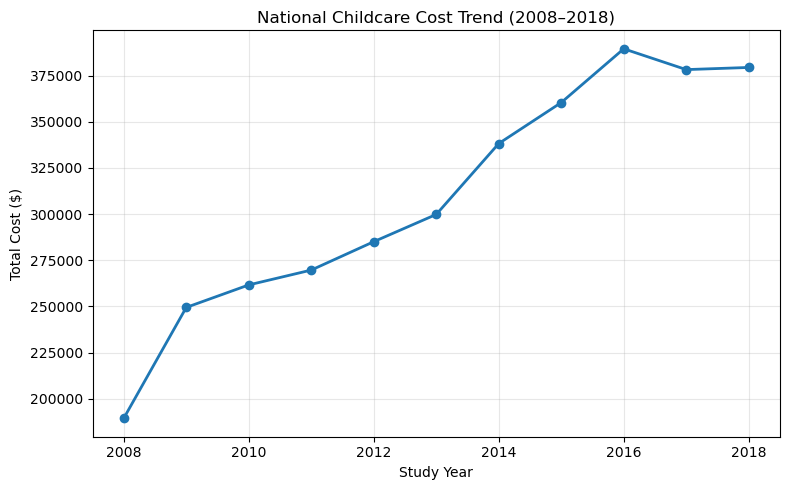

Saved: C:\Mathan\GitHub\Mathan-MS.github.io\mathan-ms.github.io\Projects\Childcare_Cost_Analysis\figures\national_childcare_cost_trend.png


In [12]:
trend_df = (
    df_clean.groupby("StudyYear")["MCInfant"]
    .sum()
    .reset_index()
    .sort_values("StudyYear")
)

plt.figure(figsize=(8, 5))
plt.plot(
    trend_df["StudyYear"],
    trend_df["MCInfant"],
    marker="o",
    linewidth=2
)

plt.title("National Childcare Cost Trend (2008–2018)")
plt.xlabel("Study Year")
plt.ylabel("Total Cost ($)")
plt.grid(alpha=0.3)
plt.tight_layout()

save_path = FIGURES_DIR / "national_childcare_cost_trend.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", save_path)


## 8. Distribution of Childcare Cost

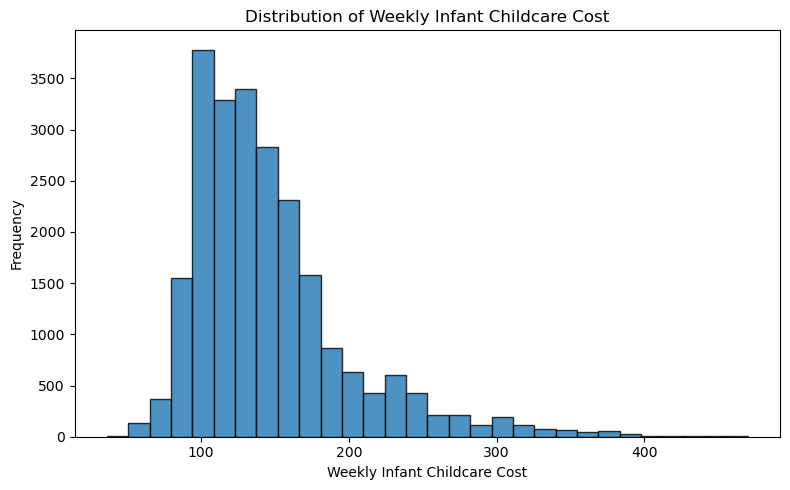

Saved: C:\Mathan\GitHub\Mathan-MS.github.io\mathan-ms.github.io\Projects\Childcare_Cost_Analysis\figures\childcare_cost_distribution.png


In [13]:
plt.figure(figsize=(8, 5))

plt.hist(
    df_clean["MCInfant"].dropna(),
    bins=30,
    edgecolor="black",
    alpha=0.8
)

plt.title("Distribution of Weekly Infant Childcare Cost")
plt.xlabel("Weekly Infant Childcare Cost")
plt.ylabel("Frequency")
plt.tight_layout()

save_path = FIGURES_DIR / "childcare_cost_distribution.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", save_path)


## 9. Income and Childcare Cost

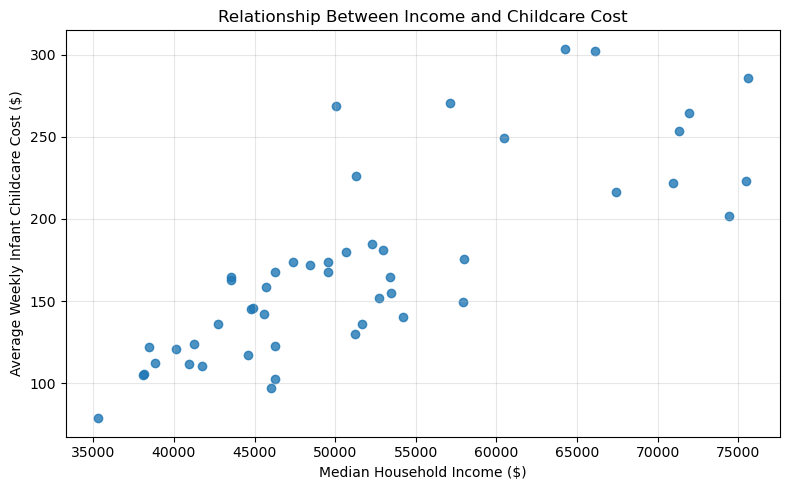

Saved: C:\Mathan\GitHub\Mathan-MS.github.io\mathan-ms.github.io\Projects\Childcare_Cost_Analysis\figures\income_vs_childcare_cost.png


In [14]:
income_col = "MHI"

income_df = df_clean[
    ["State_Name", "MCInfant", income_col]
].copy()

income_df["MCInfant"] = pd.to_numeric(
    income_df["MCInfant"],
    errors="coerce"
)

income_df[income_col] = pd.to_numeric(
    income_df[income_col],
    errors="coerce"
)

income_df = income_df.dropna()

income_state = (
    income_df.groupby("State_Name")[["MCInfant", income_col]]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8, 5))
plt.scatter(
    income_state[income_col],
    income_state["MCInfant"],
    alpha=0.8
)

plt.title("Relationship Between Income and Childcare Cost")
plt.xlabel("Median Household Income ($)")
plt.ylabel("Average Weekly Infant Childcare Cost ($)")
plt.grid(alpha=0.3)
plt.tight_layout()

save_path = FIGURES_DIR / "income_vs_childcare_cost.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", save_path)


## 10. States with the Highest Infant Childcare Costs

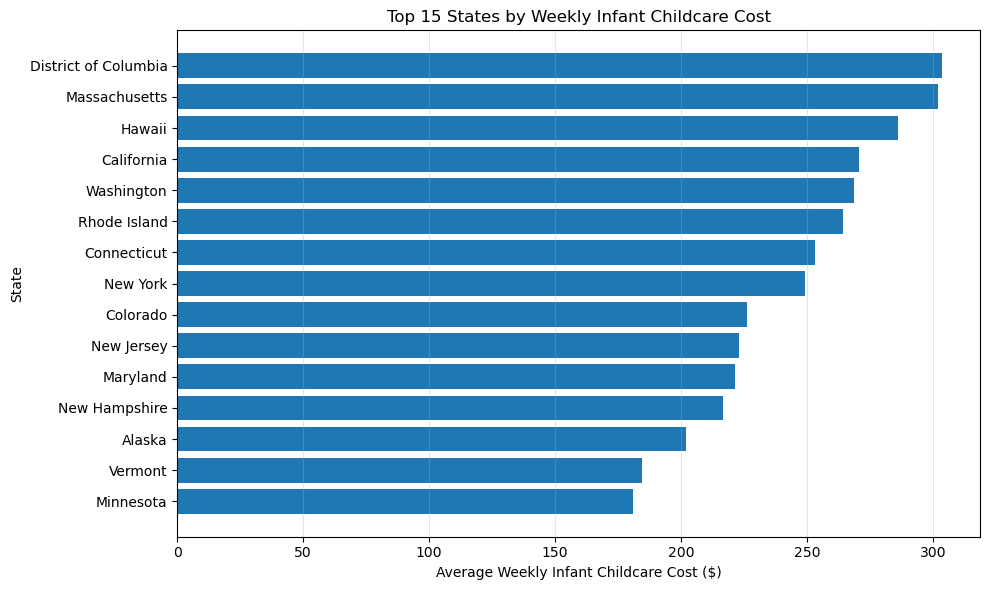

Saved: C:\Mathan\GitHub\Mathan-MS.github.io\mathan-ms.github.io\Projects\Childcare_Cost_Analysis\figures\top15_states_infant_childcare_cost.png


In [15]:
top_states = (
    df_clean.groupby("State_Name")["MCInfant"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(10, 6))
plt.barh(
    top_states.index,
    top_states.values
)

plt.title("Top 15 States by Weekly Infant Childcare Cost")
plt.xlabel("Average Weekly Infant Childcare Cost ($)")
plt.ylabel("State")
plt.gca().invert_yaxis()
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()

save_path = FIGURES_DIR / "top15_states_infant_childcare_cost.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", save_path)


## 11. States with the Lowest Infant Childcare Costs

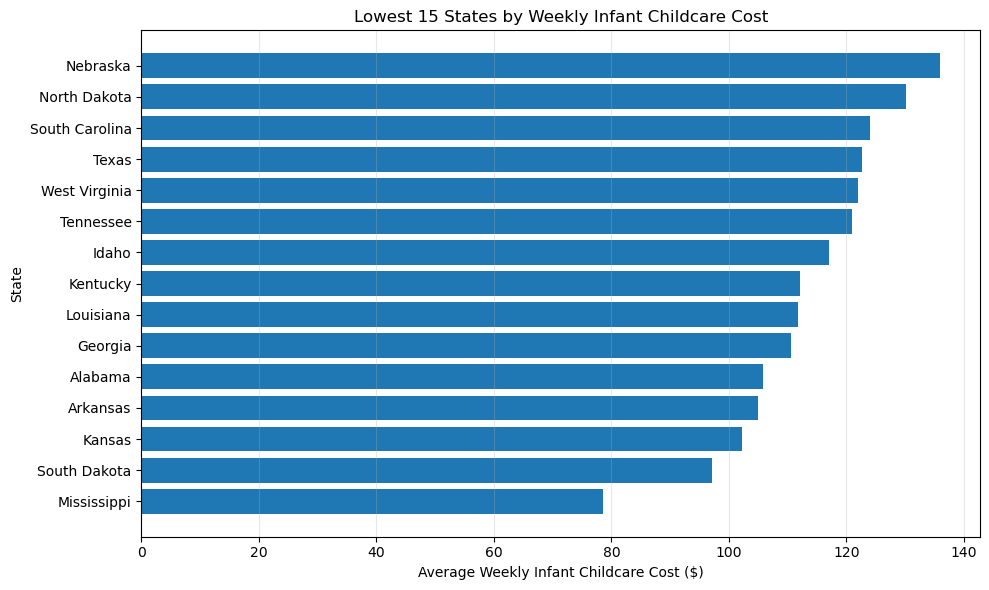

Saved: C:\Mathan\GitHub\Mathan-MS.github.io\mathan-ms.github.io\Projects\Childcare_Cost_Analysis\figures\lowest15_states_infant_childcare_cost.png


In [16]:
lowest_states = (
    df_clean.groupby("State_Name")["MCInfant"]
    .mean()
    .sort_values(ascending=True)
    .head(15)
)

plt.figure(figsize=(10, 6))
plt.barh(
    lowest_states.index,
    lowest_states.values
)

plt.title("Lowest 15 States by Weekly Infant Childcare Cost")
plt.xlabel("Average Weekly Infant Childcare Cost ($)")
plt.ylabel("State")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()

save_path = FIGURES_DIR / "lowest15_states_infant_childcare_cost.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", save_path)


## 12. Childcare Affordability Infographic

In [17]:
state_avg = df_clean.groupby("State_Name")["MCInfant"].mean() * 52

highest_state = state_avg.idxmax()
lowest_state = state_avg.idxmin()
highest_cost = state_avg.max()
lowest_cost = state_avg.min()

center_cost = df_clean["MCInfant"].mean() * 52
home_cost = df_clean["MFCCInfant"].mean() * 52

infant_cost = df_clean["MCInfant"].mean() * 52
toddler_cost = df_clean["MCToddler"].mean() * 52
preschool_cost = df_clean["MCPreschool"].mean() * 52

preschool_less_pct = (
    (df_clean["MCInfant"].mean() - df_clean["MCPreschool"].mean())
    / df_clean["MCInfant"].mean()
) * 100

provider_values = [center_cost, home_cost]
age_values = [infant_cost, toddler_cost, preschool_cost]

cost_range_df = pd.DataFrame({
    "Age Group": ["Infant", "Toddler", "Preschool"],
    "Median Cost": [
        df_clean["MCInfant"].mean() * 52,
        df_clean["MCToddler"].mean() * 52,
        df_clean["MCPreschool"].mean() * 52
    ],
    "75th Percentile Cost": [
        df_clean["_75CInfant"].mean() * 52,
        df_clean["_75CToddler"].mean() * 52,
        df_clean["_75CPreschool"].mean() * 52
    ]
})

print("Infographic values prepared.")


Infographic values prepared.


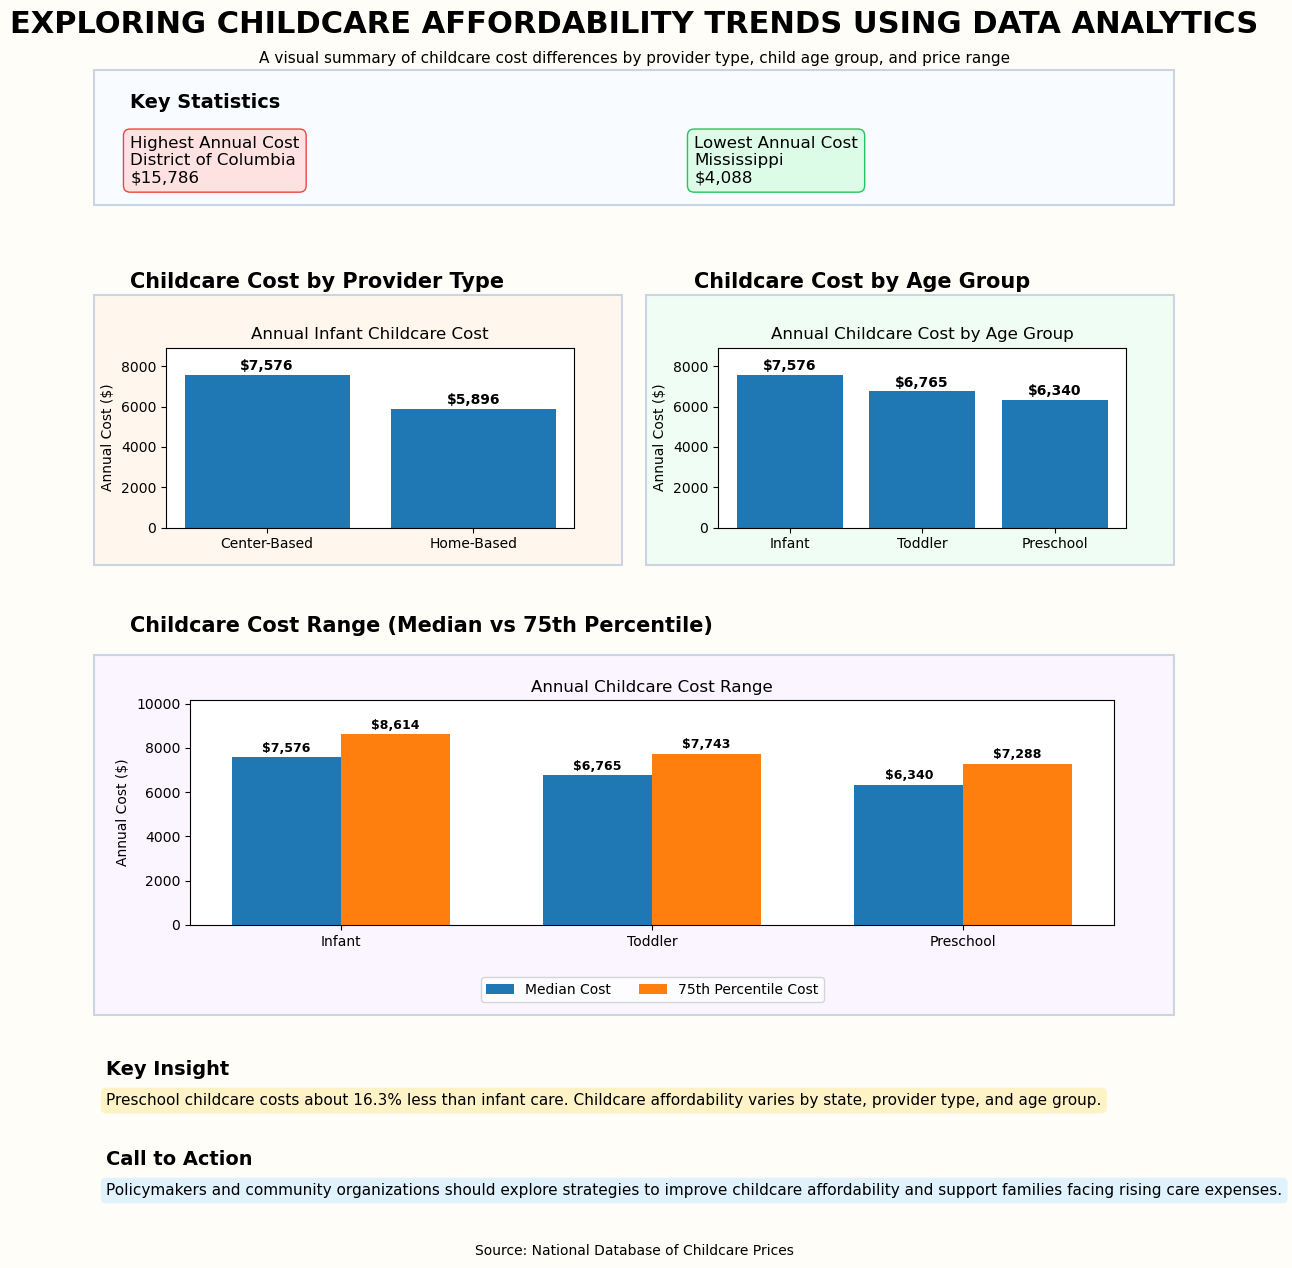

Saved: C:\Mathan\GitHub\Mathan-MS.github.io\mathan-ms.github.io\Projects\Childcare_Cost_Analysis\figures\infographic_childcare_updated.png


In [18]:
plt.close("all")

fig = plt.figure(figsize=(12, 15))
fig.patch.set_facecolor("#fffdf7")

fig.suptitle(
    "EXPLORING CHILDCARE AFFORDABILITY TRENDS USING DATA ANALYTICS",
    fontsize=22,
    fontweight="bold",
    y=0.97
)

fig.text(
    0.5,
    0.935,
    "A visual summary of childcare cost differences by provider type, child age group, and price range",
    ha="center",
    fontsize=11
)

sections = [
    (0.05, 0.84, 0.90, 0.09, "#f8fbff"),
    (0.05, 0.60, 0.44, 0.18, "#fff7ed"),
    (0.51, 0.60, 0.44, 0.18, "#f0fdf4"),
    (0.05, 0.30, 0.90, 0.24, "#faf5ff")
]

for x, y, w, h, color in sections:
    fig.add_artist(
        Rectangle(
            (x, y),
            w,
            h,
            transform=fig.transFigure,
            facecolor=color,
            edgecolor="#cbd5e1",
            linewidth=1.5,
            zorder=0
        )
    )

fig.text(
    0.08,
    0.905,
    "Key Statistics",
    fontsize=14,
    fontweight="bold"
)

fig.text(
    0.08,
    0.855,
    f"Highest Annual Cost\n{highest_state}\n${highest_cost:,.0f}",
    fontsize=12,
    bbox=dict(
        boxstyle="round,pad=0.4",
        facecolor="#fee2e2",
        edgecolor="#ef4444"
    )
)

fig.text(
    0.55,
    0.855,
    f"Lowest Annual Cost\n{lowest_state}\n${lowest_cost:,.0f}",
    fontsize=12,
    bbox=dict(
        boxstyle="round,pad=0.4",
        facecolor="#dcfce7",
        edgecolor="#22c55e"
    )
)

fig.text(
    0.08,
    0.785,
    "Childcare Cost by Provider Type",
    fontsize=15,
    fontweight="bold"
)

ax1 = fig.add_axes([0.11, 0.625, 0.34, 0.12], facecolor="#ffffff")

bars1 = ax1.bar(
    ["Center-Based", "Home-Based"],
    provider_values
)

ax1.set_title("Annual Infant Childcare Cost")
ax1.set_ylabel("Annual Cost ($)")

offset1 = max(provider_values) * 0.03

for bar, value in zip(bars1, provider_values):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        value + offset1,
        f"${value:,.0f}",
        ha="center",
        fontweight="bold"
    )

ax1.set_ylim(0, max(provider_values) * 1.18)

fig.text(
    0.55,
    0.785,
    "Childcare Cost by Age Group",
    fontsize=15,
    fontweight="bold"
)

ax2 = fig.add_axes([0.57, 0.625, 0.34, 0.12], facecolor="#ffffff")

bars2 = ax2.bar(
    ["Infant", "Toddler", "Preschool"],
    age_values
)

ax2.set_title("Annual Childcare Cost by Age Group")
ax2.set_ylabel("Annual Cost ($)")

offset2 = max(age_values) * 0.03

for bar, value in zip(bars2, age_values):
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        value + offset2,
        f"${value:,.0f}",
        ha="center",
        fontweight="bold"
    )

ax2.set_ylim(0, max(age_values) * 1.18)

fig.text(
    0.08,
    0.555,
    "Childcare Cost Range (Median vs 75th Percentile)",
    fontsize=15,
    fontweight="bold"
)

ax3 = fig.add_axes([0.13, 0.36, 0.77, 0.15], facecolor="#ffffff")

x = range(len(cost_range_df["Age Group"]))
width = 0.35

median_bars = ax3.bar(
    [i - width / 2 for i in x],
    cost_range_df["Median Cost"],
    width=width,
    label="Median Cost"
)

percentile_bars = ax3.bar(
    [i + width / 2 for i in x],
    cost_range_df["75th Percentile Cost"],
    width=width,
    label="75th Percentile Cost"
)

ax3.set_title("Annual Childcare Cost Range")
ax3.set_ylabel("Annual Cost ($)")
ax3.set_xticks(list(x))
ax3.set_xticklabels(cost_range_df["Age Group"])
ax3.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.20),
    ncol=2
)

offset3 = max(cost_range_df["75th Percentile Cost"]) * 0.03

for bar in list(median_bars) + list(percentile_bars):
    value = bar.get_height()
    ax3.text(
        bar.get_x() + bar.get_width() / 2,
        value + offset3,
        f"${value:,.0f}",
        ha="center",
        fontsize=9,
        fontweight="bold"
    )

ax3.set_ylim(
    0,
    max(cost_range_df["75th Percentile Cost"]) * 1.18
)

fig.text(
    0.06,
    0.26,
    "Key Insight",
    fontsize=14,
    fontweight="bold"
)

fig.text(
    0.06,
    0.24,
    f"Preschool childcare costs about {preschool_less_pct:.1f}% less than infant care. "
    "Childcare affordability varies by state, provider type, and age group.",
    fontsize=11,
    bbox=dict(
        boxstyle="round,pad=0.35",
        facecolor="#fef3c7",
        edgecolor="none"
    )
)

fig.text(
    0.06,
    0.20,
    "Call to Action",
    fontsize=14,
    fontweight="bold"
)

fig.text(
    0.06,
    0.18,
    "Policymakers and community organizations should explore strategies "
    "to improve childcare affordability and support families facing rising care expenses.",
    fontsize=11,
    bbox=dict(
        boxstyle="round,pad=0.35",
        facecolor="#e0f2fe",
        edgecolor="none"
    )
)

fig.text(
    0.5,
    0.14,
    "Source: National Database of Childcare Prices",
    ha="center",
    fontsize=10
)

save_path = FIGURES_DIR / "infographic_childcare_updated.png"

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

plt.show()

print("Saved:", save_path)


## 13. Saved Outputs

In [19]:
print("Figures saved:")
for file in sorted(FIGURES_DIR.glob("*.png")):
    print(" -", file.name)

print("\nResult files saved:")
for file in sorted(RESULTS_DIR.glob("*")):
    if file.is_file():
        print(" -", file.name)


Figures saved:
 - childcare_cost_distribution.png
 - income_vs_childcare_cost.png
 - infographic_childcare_updated.png
 - lowest15_states_infant_childcare_cost.png
 - national_childcare_cost_trend.png
 - top15_states_infant_childcare_cost.png

Result files saved:
 - childcare_cleaned.xlsx


## Conclusion

The analysis highlights meaningful differences in childcare affordability across states, provider types, and child age groups. The cleaned dataset and generated visualizations are saved as separate project outputs for use in the portfolio.
